In [ ]:
# for collab only
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,MinMaxScaler,TargetEncoder,StandardScaler, PolynomialFeatures
from sklearn.impute import KNNImputer,SimpleImputer
from sklearn.model_selection import train_test_split,GridSearchCV,KFold,cross_val_score, StratifiedKFold
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score,accuracy_score,classification_report, confusion_matrix, make_scorer
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB, ComplementNB

#Exploratory Data Analysis (EDA)

In [ ]:
# fifa = "/content/drive/MyDrive/Machine Learning Assignment 2/Fifa.csv"

In [ ]:
df = pd.read_csv('/content/Fifa.csv')

In [ ]:
# df = pd.read_csv("/content/Fifa.csv")

## How many rows and columns does the dataset have?

In [ ]:
rows , cols = df.shape
print(f"rows = {rows}, columns = {cols}")

rows = 19667, columns = 9


In [ ]:
df.head(20)

,Name,Country,Position,Age,Overall_Rating,Future Potential,Team,Value Per M$,Total_Stats Score
0,Agostinho Mabululu,Angola,LW,30,68,68,Ittihad Alexandria,0.650,1660
1,Mahmoud Gennesh,Egypt,GK,35,67,67,Ittihad Alexandria,0.350,1620
2,Sobhi Suleiman,Egypt,GK,28,63,65,Ittihad Alexandria,0.200,1480
3,Mahmoud Alaa,Egypt,CB,32,68,68,Ittihad Alexandria,0.500,1695
4,Mahmoud Shabana,Egypt,CB,30,66,66,Ittihad Alexandria,0.400,1640
5,Abdel Rahman Boudi,Egypt,RB,27,65,67,Ittihad Alexandria,0.450,1610
6,Karim El Deeb,Egypt,CM,33,67,67,Ittihad Alexandria,0.300,1680
7,Mohamed Tony,Egypt,CDM,29,66,67,Ittihad Alexandria,0.380,1655
8,Nour Alaa El Din,Egypt,CAM,24,64,70,Ittihad Alexandria,0.600,1590
9,Fady Farid,Egypt,ST,28,67,68,Ittihad Alexandria,0.550,1670


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19667 entries, 0 to 19666
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               19667 non-null  object 
 1   Country            19667 non-null  object 
 2   Position           19667 non-null  object 
 3   Age                19667 non-null  int64  
 4   Overall_Rating     19667 non-null  int64  
 5   Future Potential   19667 non-null  int64  
 6   Team               19667 non-null  object 
 7   Value Per M$       19667 non-null  float64
 8   Total_Stats Score  19667 non-null  int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 1.4+ MB


In [ ]:
df.describe()

,Age,Overall_Rating,Future Potential,Value Per M$,Total_Stats Score
count,19667.000000,19667.000000,19667.000000,19667.000000,19667.000000
mean,22.990034,63.225403,70.658718,2.514639,1534.513907
std,4.692410,7.812716,6.489551,7.256974,283.248088
min,15.000000,36.000000,46.000000,0.000000,416.000000
25%,19.000000,58.000000,66.000000,0.325000,1388.000000
50%,22.000000,63.000000,70.000000,0.675000,1549.000000
75%,26.000000,68.000000,75.000000,1.600000,1720.000000
max,44.000000,91.000000,95.000000,190.500000,2324.000000


In [ ]:
df.dtypes

,0
Name,object
Country,object
Position,object
Age,int64
Overall_Rating,int64
Future Potential,int64
Team,object
Value Per M$,float64
Total_Stats Score,int64


##Are there any missing values? How many, and in which columns?

In [ ]:
df.isnull().sum()

,0
Name,0
Country,0
Position,0
Age,0
Overall_Rating,0
Future Potential,0
Team,0
Value Per M$,0
Total_Stats Score,0


##Distribution of "Value Per M$"

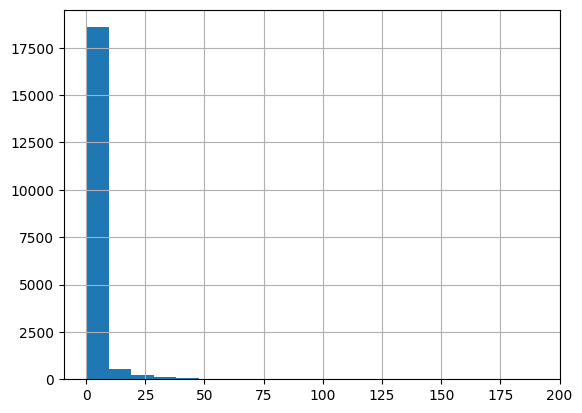

In [ ]:
df['Value Per M$'].hist(bins=20)
plt.show()

In [ ]:
# compute the skewness
df["Value Per M$"].skew()

np.float64(7.983215201865151)

In [ ]:
df.corr(numeric_only=True)["Value Per M$"].sort_values(ascending=False)

,Value Per M$
Value Per M$,1.000000
Overall_Rating,0.560648
Future Potential,0.500964
Total_Stats Score,0.385062
Age,0.142276


In [ ]:
df.groupby("Position")["Overall_Rating"].mean()

,Overall_Rating
Position,
CAM,63.679709
CB,63.544448
CDM,64.234168
CF,66.042857
CM,62.511767
GK,60.987288
LB,63.276794
LM,64.172009
LW,64.345979


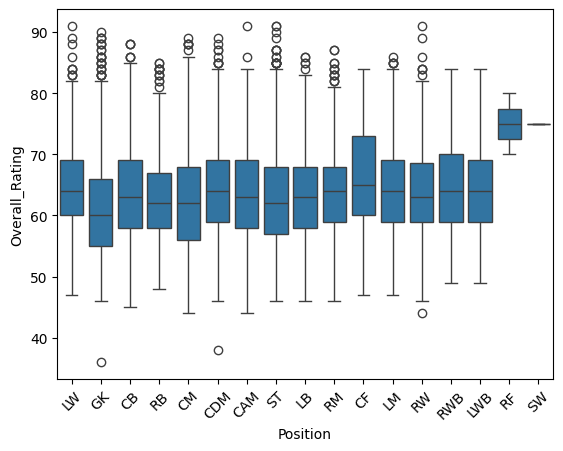

In [ ]:
sns.boxplot(x="Position", y="Overall_Rating", data=df)
plt.xticks(rotation=45)
plt.show()

#Data Preprocessing

In [ ]:
# df = pd.read_csv(fifa)
df = pd.read_csv("/content/Fifa.csv")

In [ ]:
df.duplicated().sum()

np.int64(0)

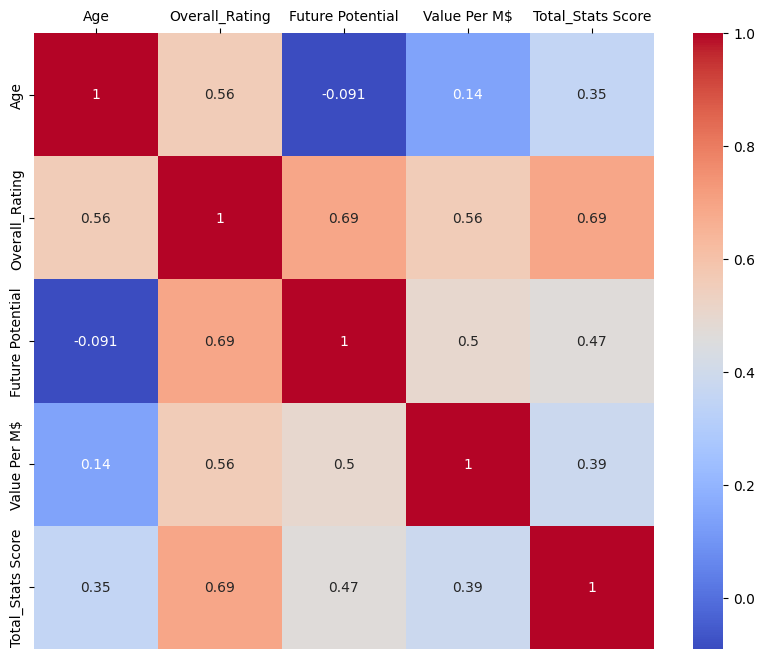

In [ ]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.gca().xaxis.tick_top()
plt.show()

## Split the dataset into Train and Test sets (80/20) before applying any preprocessing step.

In [ ]:
X = df.drop("Value Per M$", axis=1)
y = df["Value Per M$"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')

Train: (15733, 8)  |  Test: (3934, 8)


## Detect and handle outliers

In [ ]:
y_train

,Value Per M$
10156,1.300
10392,0.300
8124,3.900
13075,0.675
19445,1.300
...,...
11284,0.475
11964,1.000
5390,0.700
860,27.500


In [ ]:
# outliers in x_train
#taking only the numeric columns
cols = X_train.select_dtypes(include=[np.number]).columns

print(cols)
#looping for each column calculating iqr to remove the outliers
for col in cols:
    q1 = X_train[col].quantile(0.25)
    q3 = X_train[col].quantile(0.75)

    iqr = q3 - q1

    upper = q3 + 1.5 * iqr
    lower = q1 - 1.5 * iqr

    outliers_count = ((X_train[col] < lower) | (X_train[col] > upper)).sum()
    print(f"{col}: {outliers_count} outliers.")

    #removes the outliers by replacing the old dataframe
    # X_train[col] = X_train[col].clip(lower=lower, upper=upper)

train_data = X_train.reset_index(drop=True)

Index(['Age', 'Overall_Rating', 'Future Potential', 'Total_Stats Score'], dtype='object')
Age: 129 outliers.
Overall_Rating: 111 outliers.
Future Potential: 94 outliers.
Total_Stats Score: 666 outliers.


In [ ]:
# don't ever dare run this line it's a curse for the model supposed to be run in only certain conditions
# don't try runing this line I told you !!!
# y_train = y_train.clip(lower=lower, upper=upper)

In [ ]:
X_train

,Name,Country,Position,Age,Overall_Rating,Future Potential,Team,Total_Stats Score
10156,Mizuki Arai,Japan,LW,25,67,70,Gil Vicente,1689
10392,Juan Felipe Moreno,Colombia,ST,19,55,68,Midtjylland,1351
8124,Fábio Alexandre Silva Coentrão,Portugal,RW,32,75,75,Rio Ave,2049
13075,Luís Fellipe Rodrigues Mota,Portugal,ST,17,61,71,Belenenses,1448
19445,Juan Acosta,Uruguay,RB,28,69,69,Wanderers,1748
...,...,...,...,...,...,...,...,...
11284,Maikel Reyes,Ecuador,CM,19,59,70,Delfin,1680
11964,Visar Musliu,North Macedonia,CB,27,67,68,Ingolstadt,1557
5390,Yuki Ohashi,Japan,ST,24,63,67,Shonan Bellmare,1568
860,Wilfred Ndidi,Nigeria,CM,25,81,82,Leicester City,2042


IQR outliers in Value Per M$: 1897


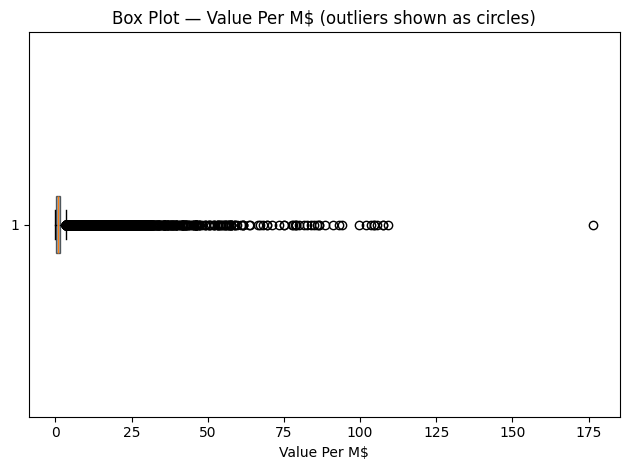

In [ ]:
# outliers for y_train
Q1 = y_train.quantile(0.25)
Q3 = y_train.quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers_iqr = y_train[(y_train <= lower) | (y_train >= upper)]
print(f'IQR outliers in Value Per M$: {len(outliers_iqr)}')

# Visualise with box plot
plt.boxplot(y_train, vert=False, patch_artist=True,
            boxprops=dict(facecolor='steelblue', alpha=0.6))
plt.title('Box Plot — Value Per M$ (outliers shown as circles)')
plt.xlabel('Value Per M$')
plt.tight_layout()
plt.show()

## Handle and Encode categorical data

In [ ]:
X_train = X_train.drop("Name", axis=1)
X_test = X_test.drop("Name", axis=1)

In [ ]:
X_train

,Country,Position,Age,Overall_Rating,Future Potential,Team,Total_Stats Score
10156,Japan,LW,25,67,70,Gil Vicente,1689
10392,Colombia,ST,19,55,68,Midtjylland,1351
8124,Portugal,RW,32,75,75,Rio Ave,2049
13075,Portugal,ST,17,61,71,Belenenses,1448
19445,Uruguay,RB,28,69,69,Wanderers,1748
...,...,...,...,...,...,...,...
11284,Ecuador,CM,19,59,70,Delfin,1680
11964,North Macedonia,CB,27,67,68,Ingolstadt,1557
5390,Japan,ST,24,63,67,Shonan Bellmare,1568
860,Nigeria,CM,25,81,82,Leicester City,2042


In [ ]:
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

In [ ]:
X_train

,Age,Overall_Rating,Future Potential,Total_Stats Score,Country_Albania,Country_Algeria,Country_Angola,Country_Argentina,Country_Armenia,Country_Australia,...,Team_Zwickau,Team_Zürich,Team_Ñublense,Team_Örebro,Team_Östersunds FK,Team_Ümraniyespor,Team_İstanbul Başakşehir,Team_İstanbulspor,Team_ŁKS Łódź,Team_Śląsk Wrocław
10156,25,67,70,1689,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
10392,19,55,68,1351,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
8124,32,75,75,2049,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
13075,17,61,71,1448,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
19445,28,69,69,1748,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,19,59,70,1680,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
11964,27,67,68,1557,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5390,24,63,67,1568,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
860,25,81,82,2042,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
X_test

,Age,Overall_Rating,Future Potential,Total_Stats Score,Country_Algeria,Country_Andorra,Country_Angola,Country_Argentina,Country_Armenia,Country_Australia,...,Team_Zhejiang,Team_Zulte-Waregem,Team_Zwickau,Team_Zürich,Team_Ñublense,Team_Östersunds FK,Team_Ümraniyespor,Team_İstanbul Başakşehir,Team_İstanbulspor,Team_Śląsk Wrocław
15659,34,68,68,1708,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1350,31,82,82,1992,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4871,22,59,65,1540,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
16532,23,68,73,1830,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
385,27,86,86,2250,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7628,32,78,78,2071,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
17406,20,56,70,1470,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5963,26,74,75,1970,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
14024,19,62,75,1606,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
# Align columns
X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

In [ ]:
X_test

,Age,Overall_Rating,Future Potential,Total_Stats Score,Country_Albania,Country_Algeria,Country_Angola,Country_Argentina,Country_Armenia,Country_Australia,...,Team_Zwickau,Team_Zürich,Team_Ñublense,Team_Örebro,Team_Östersunds FK,Team_Ümraniyespor,Team_İstanbul Başakşehir,Team_İstanbulspor,Team_ŁKS Łódź,Team_Śląsk Wrocław
15659,34,68,68,1708,0,False,False,False,False,False,...,False,False,False,0,False,False,False,False,0,False
1350,31,82,82,1992,0,False,False,False,False,False,...,False,False,False,0,False,False,False,False,0,False
4871,22,59,65,1540,0,False,False,False,False,False,...,False,False,False,0,False,False,False,False,0,False
16532,23,68,73,1830,0,False,False,False,False,False,...,False,False,False,0,False,False,False,False,0,False
385,27,86,86,2250,0,False,False,False,False,False,...,False,False,False,0,False,False,False,False,0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7628,32,78,78,2071,0,False,False,False,False,False,...,False,False,False,0,False,False,False,False,0,False
17406,20,56,70,1470,0,False,False,False,False,False,...,False,False,False,0,False,False,False,False,0,False
5963,26,74,75,1970,0,False,False,True,False,False,...,False,False,False,0,False,False,False,False,0,False
14024,19,62,75,1606,0,False,False,False,False,False,...,False,False,False,0,False,False,False,False,0,False


## Scale numerical features

In [ ]:
cat_cols = X.select_dtypes(include=['object']).columns
num_cols = X.select_dtypes(include=['int64', 'float64']).columns


scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

# X_train = scaler.fit_transform(X_train)
# X_test = scaler.transform(X_test)

In [ ]:
X_train

,Age,Overall_Rating,Future Potential,Total_Stats Score,Country_Albania,Country_Algeria,Country_Angola,Country_Argentina,Country_Armenia,Country_Australia,...,Team_Zwickau,Team_Zürich,Team_Ñublense,Team_Örebro,Team_Östersunds FK,Team_Ümraniyespor,Team_İstanbul Başakşehir,Team_İstanbulspor,Team_ŁKS Łódź,Team_Śląsk Wrocław
10156,0.427468,0.483743,-0.102151,0.547828,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
10392,-0.852089,-1.059077,-0.410505,-0.643544,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
8124,1.920283,1.512290,0.668734,1.816744,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
13075,-1.278607,-0.287667,0.052026,-0.301641,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
19445,1.067246,0.740880,-0.256328,0.755789,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,-0.852089,-0.544804,-0.102151,0.516105,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
11964,0.853986,0.483743,-0.410505,0.082558,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5390,0.214208,-0.030530,-0.564682,0.121331,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
860,0.427468,2.283700,1.747973,1.792070,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


# **linear Regression**

## baseline Linear Regression model

In [ ]:
# Model
baseline_reg_model = LinearRegression()
baseline_reg_model.fit(X_train, y_train)

# Predictions
y_train_pred = baseline_reg_model.predict(X_train)
y_test_pred  = baseline_reg_model.predict(X_test)

In [ ]:
# Metrics
def regression_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return mae, mse, rmse, r2

In [ ]:
train_metrics = regression_metrics(y_train, y_train_pred)
test_metrics  = regression_metrics(y_test, y_test_pred)

print("Baseline Linear Regression")
print(f"Train Accuracy:\n MAE: {train_metrics[0]:.3f}, MSE: {train_metrics[1]:.3f}, RMSE: {train_metrics[2]:.3f}, R2: {train_metrics[3]:.3f}")
print(f"Test  Accuracy:\n MAE: {test_metrics[0]:.3f}, MSE: {test_metrics[1]:.3f}, RMSE: {test_metrics[2]:.3f}, R2: {test_metrics[3]:.3f}")

Baseline Linear Regression
Train Accuracy:
 MAE: 2.372, MSE: 22.195, RMSE: 4.711, R2: 0.559
Test  Accuracy:
 MAE: 2.597, MSE: 29.950, RMSE: 5.473, R2: 0.517


For visualization purposes, a simplified single-feature model was used, while all reported performance metrics were obtained from the full multivariate model.

In [ ]:
# Choose one feature for visualization
X_vis = X_train[['Overall_Rating']]
y_vis = y_train.values

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


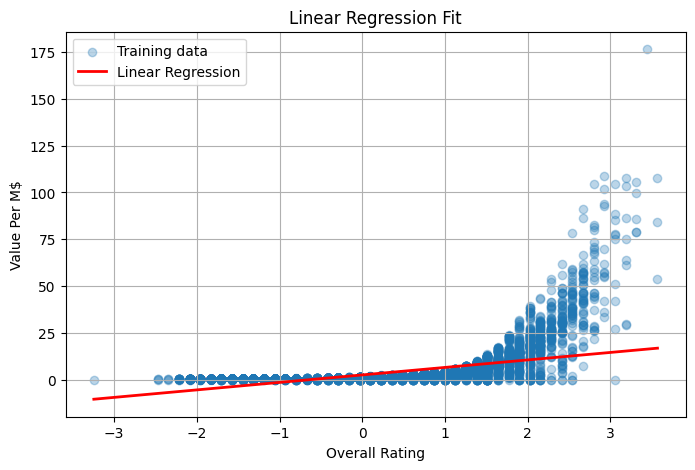

In [ ]:
lin_vis = LinearRegression()
lin_vis.fit(X_vis, y_vis)

# Generate smooth line
x_range = np.linspace(X_vis.min(), X_vis.max(), 300).reshape(-1, 1)
y_lin_pred = lin_vis.predict(x_range)

plt.figure(figsize=(8,5))
plt.scatter(X_vis, y_vis, alpha=0.3, label='Training data')
plt.plot(x_range, y_lin_pred, color='red', linewidth=2, label='Linear Regression')
plt.xlabel("Overall Rating")
plt.ylabel("Value Per M$")
plt.title("Linear Regression Fit")
plt.legend()
plt.grid(True)
plt.show()

## Polynomial Regression (Numerical Features only)

In [ ]:
num_cols = ['Age', 'Overall_Rating', 'Future Potential', 'Total_Stats Score']

In [ ]:
train_r2 = []
test_r2 = []
degrees = [1, 2, 3, 4]

for d in degrees:
    poly = PolynomialFeatures(degree=d, include_bias=False)

    X_train_poly = poly.fit_transform(X_train[num_cols])
    X_test_poly  = poly.transform(X_test[num_cols])

    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    train_r2.append(r2_score(y_train, model.predict(X_train_poly)))
    test_r2.append(r2_score(y_test, model.predict(X_test_poly)))

    print(f"Degree {d} -> Train R2: {train_r2[-1]:.3f}, Test R2: {test_r2[-1]:.3f}")

Degree 1 -> Train R2: 0.361, Test R2: 0.342
Degree 2 -> Train R2: 0.742, Test R2: 0.723
Degree 3 -> Train R2: 0.933, Test R2: 0.919
Degree 4 -> Train R2: 0.975, Test R2: 0.970


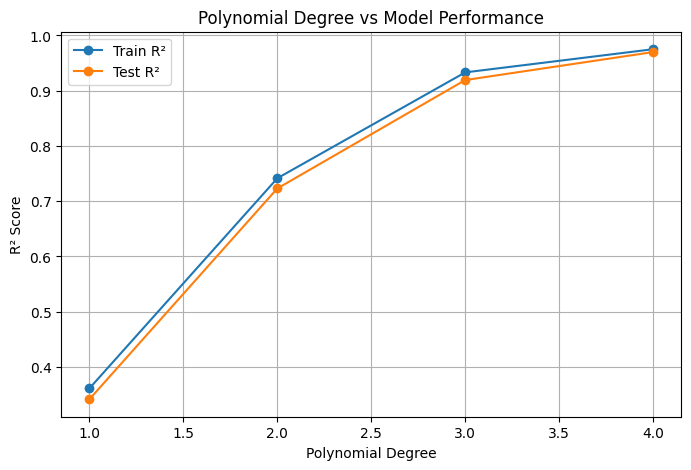

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(degrees, train_r2, marker='o', label='Train R²')
plt.plot(degrees, test_r2, marker='o', label='Test R²')
plt.xlabel("Polynomial Degree")
plt.ylabel("R² Score")
plt.title("Polynomial Degree vs Model Performance")
plt.legend()
plt.grid(True)
plt.show()

**Degree vs Performance Trend**

As the polynomial degree increases, the training R² consistently improves, indicating that the model becomes more flexible and fits the training data better.

In [ ]:
# best degree = 4 (degree with highest Test R² and small gap)
best_degree = degrees[np.argmax(test_r2)]
print("Best polynomial degree:", best_degree)

Best polynomial degree: 4


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


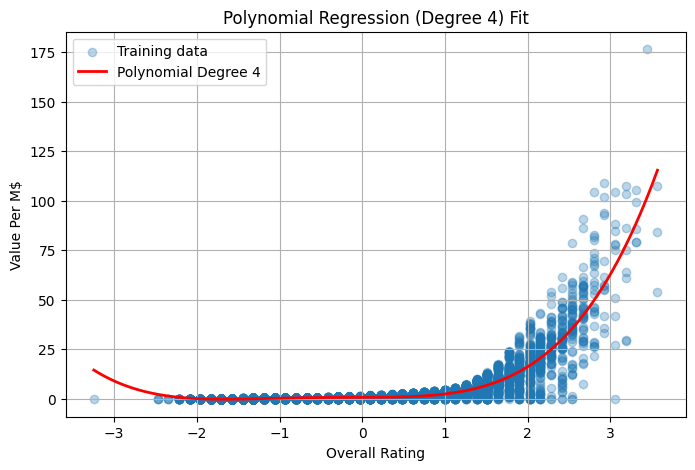

In [ ]:
poly4 = PolynomialFeatures(degree=4, include_bias=False)
X_vis_poly = poly4.fit_transform(X_vis)
x_range_poly = poly4.transform(x_range)

poly4_model = LinearRegression()
poly4_model.fit(X_vis_poly, y_vis)

y_poly_pred = poly4_model.predict(x_range_poly)

plt.figure(figsize=(8,5))
plt.scatter(X_vis, y_vis, alpha=0.3, label='Training data')
plt.plot(x_range, y_poly_pred, color='red', linewidth=2, label='Polynomial Degree 4')
plt.xlabel("Overall Rating")
plt.ylabel("Value Per M$")
plt.title("Polynomial Regression (Degree 4) Fit")
plt.legend()
plt.grid(True)
plt.show()

Degree 4 polynomial model → curved, captures non-linear relationship

## Regularization (Ridge & Lasso)

In [ ]:
# Prepare polynomial features
poly = PolynomialFeatures(degree=best_degree, include_bias=False)
X_train_poly = poly.fit_transform(X_train[num_cols])
X_test_poly  = poly.transform(X_test[num_cols])

## Ridge Regression (L2)

In [ ]:
alphas = np.logspace(-3, 3, 20)

ridge_train_rmse = []
ridge_test_rmse = []

for a in alphas:
    ridge = Ridge(alpha=a)
    ridge.fit(X_train_poly, y_train)

    ridge_train_rmse.append(
        np.sqrt(mean_squared_error(y_train, ridge.predict(X_train_poly)))
    )
    ridge_test_rmse.append(
        np.sqrt(mean_squared_error(y_test, ridge.predict(X_test_poly)))
    )

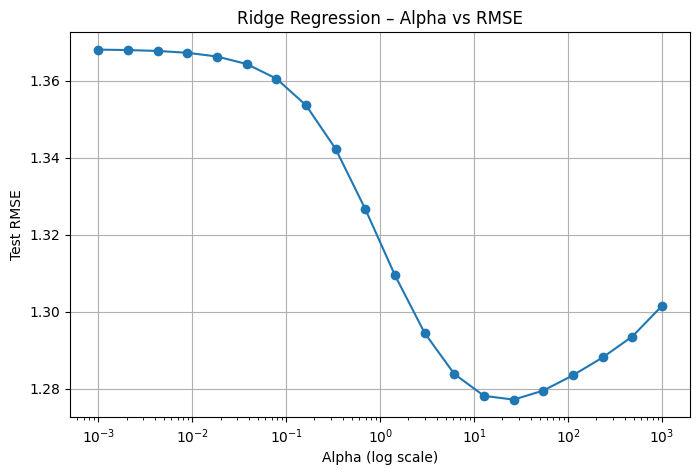

Best Ridge alpha: 26.366508987303554


In [ ]:
# Plot Ridge RMSE
plt.figure(figsize=(8,5))
plt.semilogx(alphas, ridge_test_rmse, marker='o')
plt.xlabel("Alpha (log scale)")
plt.ylabel("Test RMSE")
plt.title("Ridge Regression – Alpha vs RMSE")
plt.grid(True)
plt.show()

best_ridge_alpha = alphas[np.argmin(ridge_test_rmse)]
print("Best Ridge alpha:", best_ridge_alpha)

## Lasso Regression (L1)

In [ ]:
lasso_train_rmse = []
lasso_test_rmse = []

for a in alphas:
    lasso = Lasso(alpha=a, max_iter=5000)
    lasso.fit(X_train_poly, y_train)

    lasso_train_rmse.append(
        np.sqrt(mean_squared_error(y_train, lasso.predict(X_train_poly)))
    )
    lasso_test_rmse.append(
        np.sqrt(mean_squared_error(y_test, lasso.predict(X_test_poly)))
    )

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.709e+03, tolerance: 7.916e+01
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.109e+02, tolerance: 7.916e+01
  model = cd_fast.enet_coordinate_descent(


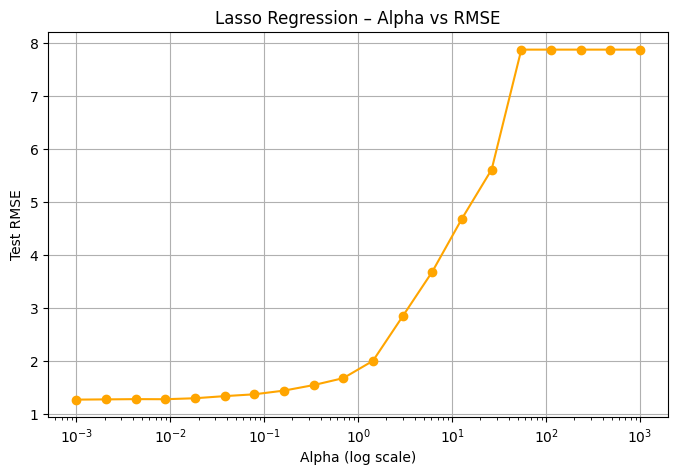

Best Lasso alpha: 0.001


In [ ]:
plt.figure(figsize=(8,5))
plt.semilogx(alphas, lasso_test_rmse, marker='o', color='orange')
plt.xlabel("Alpha (log scale)")
plt.ylabel("Test RMSE")
plt.title("Lasso Regression – Alpha vs RMSE")
plt.grid(True)
plt.show()

best_lasso_alpha = alphas[np.argmin(lasso_test_rmse)]
print("Best Lasso alpha:", best_lasso_alpha)

## Did Lasso Zero Out Features?

In [ ]:
lasso_best = Lasso(alpha=best_lasso_alpha, max_iter=5000)
lasso_best.fit(X_train_poly, y_train)

zero_coeffs = np.sum(lasso_best.coef_ == 0)
total_coeffs = len(lasso_best.coef_)

print(f"Lasso zeroed out {zero_coeffs} out of {total_coeffs} features")

Lasso zeroed out 7 out of 69 features


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.709e+03, tolerance: 7.916e+01
  model = cd_fast.enet_coordinate_descent(


# Logistic Regression

In [ ]:
# Create Performance Tier
q1 = df["Overall_Rating"].quantile(0.25)
q2 = df["Overall_Rating"].quantile(0.50)
q3 = df["Overall_Rating"].quantile(0.75)
print(q1, q2, q3)


58.0 63.0 68.0


In [ ]:
def classify_tier(x):
    if x <= q1:
        return "Low"
    elif x <= q2:
        return "Mid"
    elif x <= q3:
        return "High"
    else:
        return "Elite"

# Apply the classification function to create the new target column
df["Performance_Tier"] = df["Overall_Rating"].apply(classify_tier)
# Show how many players fall into each category
print(df["Performance_Tier"].value_counts())

Performance_Tier
Low      5568
Mid      5102
Elite    4700
High     4297
Name: count, dtype: int64


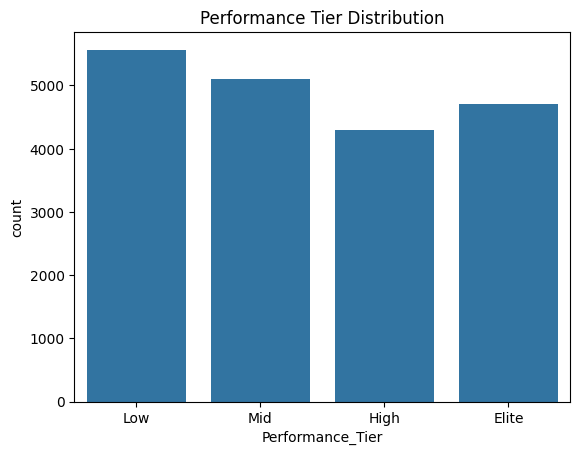

In [ ]:
# Plot the distribution of players across performance tiers
sns.countplot(x="Performance_Tier", data=df, order=["Low","Mid","High","Elite"])
plt.title("Performance Tier Distribution")
plt.show()

Decide the threshold / justify it:

The thresholds were chosen using percentiles of the Overall_Rating column

Q1 (25%) = 58

Q2 (50%) = 63

Q3 (75%) = 68

Based on this players were divided into four groups:

Low: ≤ 58

Mid: 59–63

High: 64–68

Elite: > 68

This method was used because percentiles reflect the real data distribution and give a balanced split between classes instead of random thresholds

In [ ]:
# Define features (X) by dropping target and leakage columns:
# Value Per M$: target for regression  and we dont need it
#  Performance_Tier: our target
#  Overall_Rating: must nOT be included as a feature.
# Name: irrelevant identifier feature

X_cls = df.drop(["Value Per M$", "Performance_Tier", "Overall_Rating", "Name"], axis=1)

# Define target what we want to predict
y_cls = df["Performance_Tier"]

In [ ]:
 # stratify makes sure each class has the same proportion in train and test sets
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)

In [ ]:
# Show distribution after split
print("Train distribution:")
print(y_train_cls.value_counts())
print("\nTest distribution:")
print(y_test_cls.value_counts())

Train distribution:
Performance_Tier
Low      4454
Mid      4081
Elite    3760
High     3438
Name: count, dtype: int64

Test distribution:
Performance_Tier
Low      1114
Mid      1021
Elite     940
High      859
Name: count, dtype: int64


In [ ]:
# Convert categorical columns into numerical columns using one hot encoding
# drop_first=True to avoid dummy variable trap (reduces redundancy)
X_train_cls = pd.get_dummies(X_train_cls, drop_first=True)
X_test_cls = pd.get_dummies(X_test_cls, drop_first=True)
X_train_cls, X_test_cls = X_train_cls.align(X_test_cls, join="left", axis=1, fill_value=0)

In [ ]:
# Select numerical columns that need scaling
num_cols_cls = ["Age", "Future Potential", "Total_Stats Score"]

scaler_cls = StandardScaler()
X_train_cls[num_cols_cls] = scaler_cls.fit_transform(X_train_cls[num_cols_cls])
X_test_cls[num_cols_cls] = scaler_cls.transform(X_test_cls[num_cols_cls])


We used another separate train/test split, encoding, and scaling bec classification pipeline uses a completely separate train/test split, encoding, and scaler from the regression pipeline. This is because the target variable changed from Value Per M$ to Performance_Tier and fitting the scaler on the full data would cause data leakage so each pipeline must be independent

# Baseline Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

log_reg = LogisticRegression(max_iter=2000)

# Train the model on training data
log_reg.fit(X_train_cls, y_train_cls)

# Predict on test data
y_pred = log_reg.predict(X_test_cls)

# Evaluate model performance using accuracy
print("Accuracy:", accuracy_score(y_test_cls, y_pred))

# print precision, recall, f1-score for each class
print("\nClassification Report:\n")
print(classification_report(y_test_cls, y_pred))

Accuracy: 0.8045246568378241

Classification Report:

              precision    recall  f1-score   support

       Elite       0.88      0.88      0.88       940
        High       0.70      0.67      0.69       859
         Low       0.89      0.90      0.89      1114
         Mid       0.73      0.74      0.73      1021

    accuracy                           0.80      3934
   macro avg       0.80      0.80      0.80      3934
weighted avg       0.80      0.80      0.80      3934



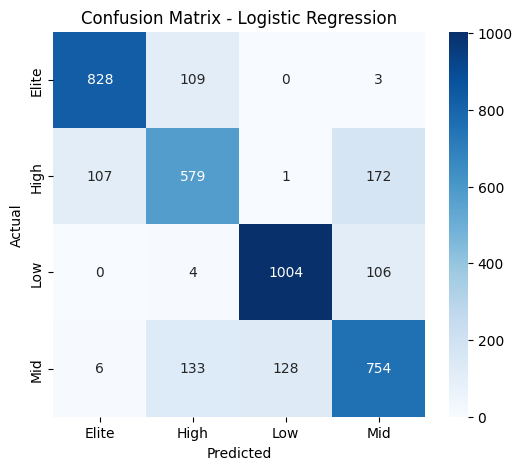

In [ ]:
cm = confusion_matrix(y_test_cls, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=log_reg.classes_,
            yticklabels=log_reg.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [ ]:
import numpy as np

# Generate different values of C (regularization strength) on a log scale
C_values = np.logspace(-3, 3, 10)

train_acc = []
test_acc = []

# Loop over different C values to find the best regularization strength
for c in C_values:
  # Initialize Logistic Regression with current C value
    model = LogisticRegression(C=c, max_iter=2000, solver='lbfgs')
    model.fit(X_train_cls, y_train_cls)

    tr = model.score(X_train_cls, y_train_cls)
    te = model.score(X_test_cls, y_test_cls)

    train_acc.append(tr)
    test_acc.append(te)

    print(f"C={c:.5f} | Train Acc: {tr:.4f} | Test Acc: {te:.4f}")

best_C = C_values[np.argmax(test_acc)]
print(f"\nBest C: {best_C:.5f}")

C=0.00100 | Train Acc: 0.7400 | Test Acc: 0.7278
C=0.00464 | Train Acc: 0.7846 | Test Acc: 0.7722
C=0.02154 | Train Acc: 0.8061 | Test Acc: 0.7926
C=0.10000 | Train Acc: 0.8235 | Test Acc: 0.8005
C=0.46416 | Train Acc: 0.8452 | Test Acc: 0.8043
C=2.15443 | Train Acc: 0.8652 | Test Acc: 0.8030
C=10.00000 | Train Acc: 0.8721 | Test Acc: 0.7931
C=46.41589 | Train Acc: 0.8734 | Test Acc: 0.7903
C=215.44347 | Train Acc: 0.8743 | Test Acc: 0.7888
C=1000.00000 | Train Acc: 0.8748 | Test Acc: 0.7875

Best C: 0.46416


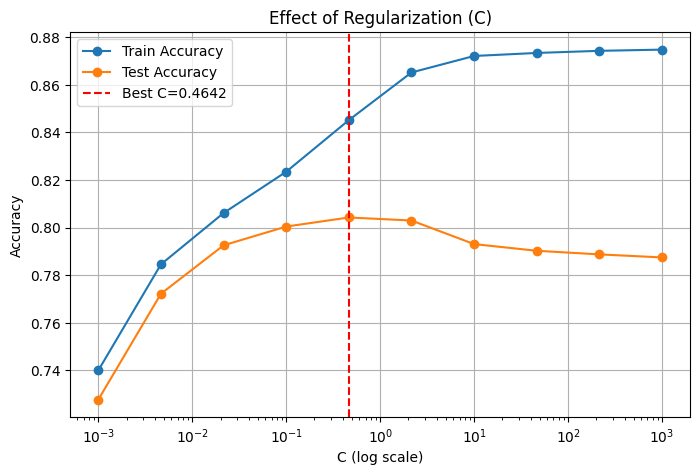

In [ ]:
# Plot how regularization strength (C) affects model performance
plt.figure(figsize=(8,5))

plt.plot(C_values, train_acc, marker='o', label='Train Accuracy')
plt.plot(C_values, test_acc, marker='o', label='Test Accuracy')

plt.xscale('log')
plt.xlabel("C (log scale)")
plt.ylabel("Accuracy")
plt.title("Effect of Regularization (C)")
plt.axvline(x=best_C, color="red", linestyle="--", label=f"Best C={best_C:.4f}")
plt.legend()
plt.grid()

plt.show()

In [ ]:
# Find C value that give the highest test accuracy
best_index = np.argmax(test_acc)
best_C = C_values[best_index]

print("Best C:", best_C)
print("Best Test Accuracy:", test_acc[best_index])
print("Best Train Accuracy:", train_acc[best_index])

Best C: 0.46415888336127775
Best Test Accuracy: 0.8042704626334519
Best Train Accuracy: 0.8451662111485413


In [ ]:
# Compare L2 vs L1 regularization using the best C value

# L2
log_l2 = LogisticRegression(C=best_C, penalty='l2', solver='lbfgs', max_iter=2000)
log_l2.fit(X_train_cls, y_train_cls)

y_pred_l2 = log_l2.predict(X_test_cls)

# L1
log_l1 = LogisticRegression(C=best_C, penalty='l1', solver='saga', max_iter=2000)
log_l1.fit(X_train_cls, y_train_cls)

y_pred_l1 = log_l1.predict(X_test_cls)

print("L2 Accuracy:", accuracy_score(y_test_cls, y_pred_l2))
print("L1 Accuracy:", accuracy_score(y_test_cls, y_pred_l1))

L2 Accuracy: 0.8042704626334519
L1 Accuracy: 0.8012201321809863


In [ ]:
# Check how many features L1 zeroed out
import numpy as np
zeroed = np.sum(log_l1.coef_ == 0)
total = log_l1.coef_.size
print(f"Zeroed features: {zeroed} / {total}")

Zeroed features: 4233 / 4684


L1 removed 90% of features 4233 out of 4684 but accuracy barely changed compared to L2 This means most of the removed features were useless Team/Country columns Only 10% of features were actually needed to get 80% accuracy mainly Future Potential and Total_Stats Score."

Even without Overall_Rating the model still got 80% accuracy because Future Potential and Total_Stats Score are highly correlated with it (0.69) So the model is basically learning the same thing through different features.

# Naïve Bayes Classification


 ## thresholds for each category.


In [ ]:
dataset_classifier ='Overall_Rating'
# calculating the thresholds using quantile
print(df[dataset_classifier].describe())
print("\nPercentiles:")
print(df[dataset_classifier].quantile([0, 0.25, 0.50, 0.75, 1]))

count    19667.000000
mean        63.225403
std          7.812716
min         36.000000
25%         58.000000
50%         63.000000
75%         68.000000
max         91.000000
Name: Overall_Rating, dtype: float64

Percentiles:
0.00    36.0
0.25    58.0
0.50    63.0
0.75    68.0
1.00    91.0
Name: Overall_Rating, dtype: float64


In [ ]:
labels = ['Low', 'Mid', 'High', 'Elite']

bins = df[dataset_classifier].quantile([0, 0.25, 0.50, 0.75, 1]).values

## data distribution histogram

In [ ]:
df = pd.read_csv('/content/Fifa.csv')

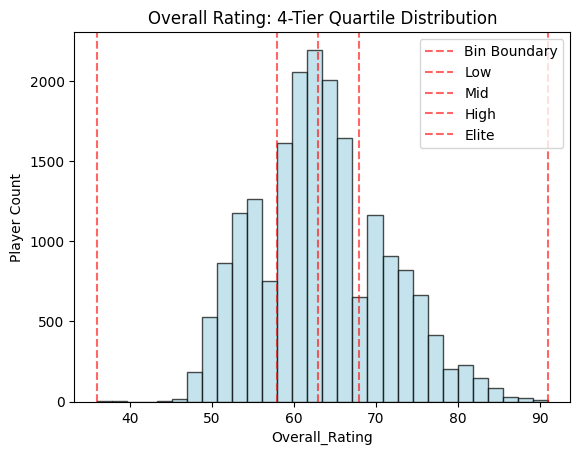

In [ ]:
plt.hist(df[dataset_classifier], bins=30, color='lightblue', edgecolor='black', alpha=0.7)
# Add vertical lines at the quartile boundaries
for bin_edge in bins:
    plt.axvline(bin_edge, color='red', linestyle='--', alpha=0.6)

plt.title("Overall Rating: 4-Tier Quartile Distribution")
plt.xlabel(dataset_classifier)
plt.ylabel("Player Count")
plt.legend(['Bin Boundary'] + labels, loc='upper right')
plt.show()

In [ ]:
# assign each player to their tier
def assign_tier(score,bins):
    if score < bins[1]:
        return 0
    elif score < bins[2]:
        return 1
    elif score < bins[3]:
        return 2
    else:
        return 3
df['Tier'] = df[dataset_classifier].apply(lambda score: assign_tier(score, bins))

# show number of players for each tier before splits
counts_tiers = df['Tier'].value_counts().sort_index().values
print(f"Low: {counts_tiers[0]} | Mid: {counts_tiers[1]} | High: {counts_tiers[2]} | Elite: {counts_tiers[3]}")

Low: 4807 | Mid: 4791 | High: 4717 | Elite: 5352


In [ ]:
# splits the data 80/20
X = df.drop(columns=['Value Per M$', 'Tier', 'Name'])
y = df['Tier']

X_train, X_test, y_train_tier, y_test_tier = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## how many players fall into each category after splitting

In [ ]:
# Show counts after splitting
print(f"\nTrain set tier distribution:")
print(y_train_tier.value_counts().sort_index())
print(f"\nTest set tier distribution:")
print(y_test_tier.value_counts().sort_index())


Train set tier distribution:
Tier
0    3845
1    3833
2    3774
3    4281
Name: count, dtype: int64

Test set tier distribution:
Tier
0     962
1     958
2     943
3    1071
Name: count, dtype: int64


## Plot a bar chart showing the class distribution.

The data is balanced because of splitting the data by quartiles, making sure every part has nearly the same amount of players.


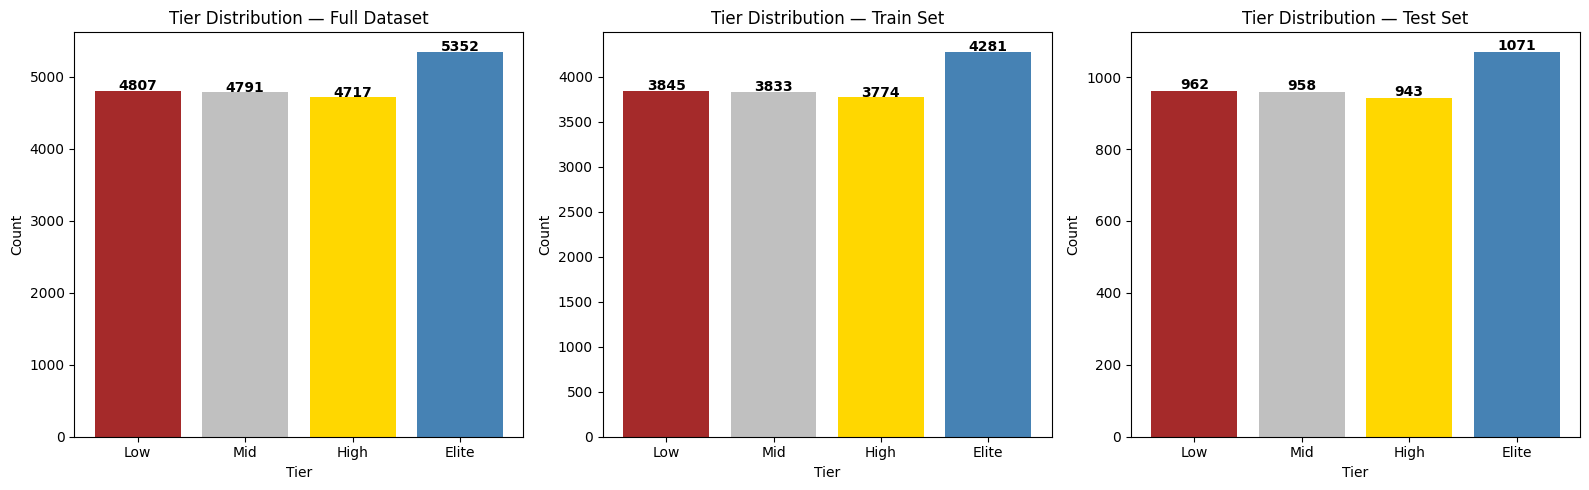

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

tier_labels = ['Low', 'Mid', 'High', 'Elite']
colors = ['brown', 'silver', 'gold', 'steelblue']
datasets = [df['Tier'], y_train_tier, y_test_tier]
titles = ['Full Dataset', 'Train Set', 'Test Set']

for ax, data, title in zip(axes, datasets, titles):
    counts = data.value_counts().sort_index()
    ax.bar(tier_labels, counts, color=colors)
    ax.set_title(f"Tier Distribution — {title}")
    ax.set_xlabel("Tier")
    ax.set_ylabel("Count")
    for i, v in enumerate(counts):
        ax.text(i, v + 5, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# encode the categorical columns for the BernoulliNB and ComplementNB
categorical_cols = ['Country', 'Position', 'Team']
ohe_nb = OneHotEncoder(handle_unknown="ignore", sparse_output=False).set_output(transform='pandas')

encoded_train_nb = ohe_nb.fit_transform(X_train[categorical_cols])
encoded_test_nb = ohe_nb.transform(X_test[categorical_cols])

X_train_ohe = pd.concat([X_train.drop(columns=categorical_cols), encoded_train_nb], axis=1)
X_test_ohe = pd.concat([X_test.drop(columns=categorical_cols), encoded_test_nb], axis=1)

X_train_ohe, X_test_ohe = X_train_ohe.align(X_test_ohe, join="left", axis=1, fill_value=0)

## Most appropriate Naïve Bayes variant

GaussianNB is the most appropriate and that because Future Potential, Total_Stats Score and age nearly follows normal distribution which is prefect for GaussianNB because it **"Assumes features follow normal distribution"**

### Evaluate using: Accuracy, Precision, Recall, F1-score

In [ ]:
# GaussianNB  without scaling
num_features = ['Age', 'Future Potential', 'Total_Stats Score']

gnb = GaussianNB()
gnb.fit(X_train[num_features], y_train_tier)
y_pred_gnb = gnb.predict(X_test[num_features])
print("GaussianNB (no scaling):")
print(classification_report(y_test_tier, y_pred_gnb,target_names=['Low','Mid','High','Elite']))

GaussianNB (no scaling):
              precision    recall  f1-score   support

         Low       0.79      0.77      0.78       962
         Mid       0.58      0.64      0.61       958
        High       0.63      0.64      0.63       943
       Elite       0.87      0.81      0.84      1071

    accuracy                           0.72      3934
   macro avg       0.72      0.71      0.72      3934
weighted avg       0.72      0.72      0.72      3934



In [ ]:
# GaussianNB with StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[num_features])
X_test_scaled  = scaler.transform(X_test[num_features])

gnb_scaled = GaussianNB()
gnb_scaled.fit(X_train_scaled, y_train_tier)
y_pred_gnb_scaled = gnb_scaled.predict(X_test_scaled)
print("GaussianNB (with StandardScaler):")
print(classification_report(y_test_tier, y_pred_gnb_scaled,target_names=['Low','Mid','High','Elite']))


GaussianNB (with StandardScaler):
              precision    recall  f1-score   support

         Low       0.79      0.77      0.78       962
         Mid       0.58      0.64      0.61       958
        High       0.63      0.64      0.63       943
       Elite       0.87      0.81      0.84      1071

    accuracy                           0.72      3934
   macro avg       0.72      0.71      0.72      3934
weighted avg       0.72      0.72      0.72      3934



## Scaling Sensitivity

scaling doesn't affect its performance. Naïve Bayes uses Mean and Variance for calculations **P(x | class) = Gaussian(x, μ, σ²)** when scaling The relative distances between values stay exactly the same

In [ ]:
# BernoulliNB using full OHE feature dataset
bnb = BernoulliNB()
bnb.fit(X_train_ohe, y_train_tier)
y_pred_bnb = bnb.predict(X_test_ohe)
print("BernoulliNB:")
print(classification_report(y_test_tier, y_pred_bnb,target_names=['Low','Mid','High','Elite']))

BernoulliNB:
              precision    recall  f1-score   support

         Low       0.55      0.68      0.61       962
         Mid       0.39      0.27      0.32       958
        High       0.43      0.36      0.39       943
       Elite       0.57      0.70      0.63      1071

    accuracy                           0.51      3934
   macro avg       0.49      0.50      0.49      3934
weighted avg       0.49      0.51      0.49      3934



In [ ]:
# ComplementNB using full OHE feature dataset and using MinMax scaler to avoid negative
mm = MinMaxScaler()
X_train_mm = mm.fit_transform(X_train_ohe)
X_test_mm  = mm.transform(X_test_ohe)

cnb = ComplementNB()
cnb.fit(X_train_mm, y_train_tier)
y_pred_cnb = cnb.predict(X_test_mm)
print("ComplementNB:")
print(classification_report(y_test_tier, y_pred_cnb,target_names=['Low','Mid','High','Elite']))

ComplementNB:
              precision    recall  f1-score   support

         Low       0.54      0.70      0.61       962
         Mid       0.40      0.25      0.31       958
        High       0.42      0.34      0.38       943
       Elite       0.58      0.72      0.65      1071

    accuracy                           0.51      3934
   macro avg       0.49      0.50      0.49      3934
weighted avg       0.49      0.51      0.49      3934



## Confusion Matrix

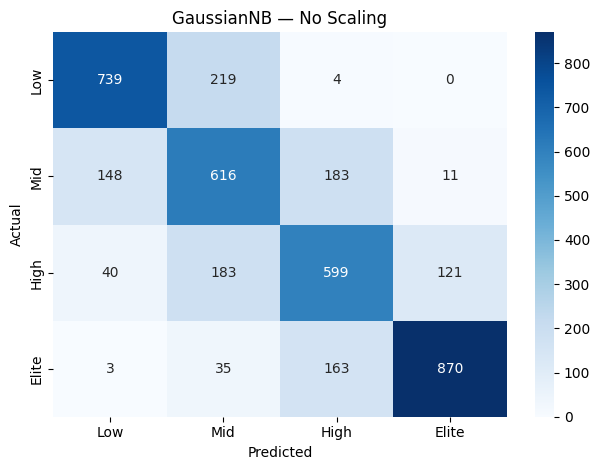

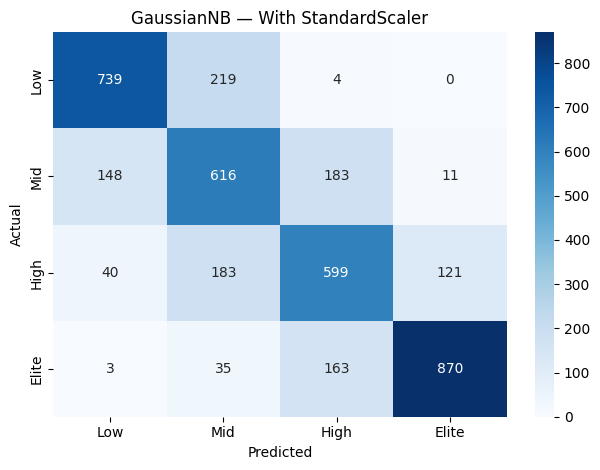

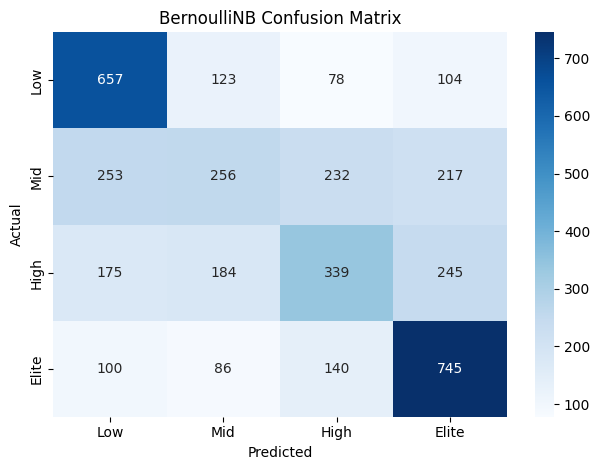

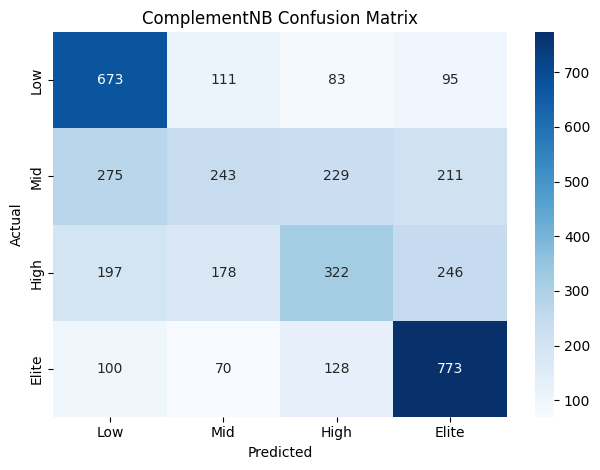

In [ ]:
# Confusion Matrices for all models
def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Low','Mid','High','Elite'],
                yticklabels=['Low','Mid','High','Elite'])
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

plot_cm(y_test_tier, y_pred_gnb,        "GaussianNB — No Scaling")
plot_cm(y_test_tier, y_pred_gnb_scaled, "GaussianNB — With StandardScaler")
plot_cm(y_test_tier, y_pred_bnb,        "BernoulliNB Confusion Matrix")
plot_cm(y_test_tier, y_pred_cnb,        "ComplementNB Confusion Matrix")

# Model Evaluation with Cross-Validation

***A. K-Fold Cross-Validation (Regression)***

___Results___

RMSE by fold: [2.31043844 1.49039316 1.45115556 1.8187     1.5315649 ]

Mean RMSE: 1.7204504119379138

Std RMSE: 0.3221374412122701




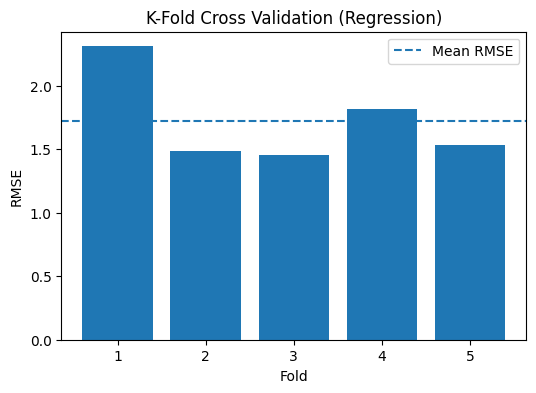

In [ ]:
# Numerical columns used in poly
num_cols = ['Age', 'Future Potential', 'Total_Stats Score','Overall_Rating']

# Model will see these columns & learn from them
X_reg = df[num_cols]
y_reg = df["Value Per M$"] # Target

# Build the best Model (Polynomial degree 4 + Linear Regression)
best_regression_model = Pipeline([
    ('poly', PolynomialFeatures(degree=best_degree, include_bias=False)),
    ('model', LinearRegression())
]) # Convert the data into bigger features and take these features to make prediction


# divide data into 5 parts
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Make scoring = RMSE instead of MSE
scoring = "neg_root_mean_squared_error"  # sklearn will make this with -ve sign ,so we will convert it into +ve sign

# Make train & test 5 times and give score for each time
rmse_scores = cross_val_score(best_regression_model, X_reg, y_reg, cv=kf, scoring="neg_root_mean_squared_error")

rmse_scores = -rmse_scores # To make it with +ve sign

# Print the results
print("___Results___")
print("\nRMSE by fold:", rmse_scores) # gives us RMSE for each fold
print("\nMean RMSE:", np.mean(rmse_scores)) # Average for the general performance
print("\nStd RMSE:", np.std(rmse_scores)) # gives us the Standard deviation
print("\n")
# Visualize
plt.figure(figsize=(6,4))
plt.bar(range(1,6), rmse_scores)
plt.axhline(np.mean(rmse_scores), linestyle='--', label='Mean RMSE')
plt.title("K-Fold Cross Validation (Regression)")
plt.xlabel("Fold")
plt.ylabel("RMSE")
plt.legend()
plt.show()




**The model shows stable performance across folds with a low standard deviation (0.32), indicating good generalization ability. Although slight variation appears in some folds, the overall performance is consistent.**

***B. Stratified K-Fold Cross-Validation (Classification)***

___Logistic Regression___

Accuracy per fold: [0.7972672386399746, 0.7982205274864951, 0.8087067047982205, 0.810553083280356, 0.8086458995549904]

Mean: 0.8046786907520074

std: 0.005711560655250755

___Naive Bayes___

Accuracy per fold: [0.42071814426437876, 0.4184938036224976, 0.40800762631077214, 0.4233947870311507, 0.4186268277177368]

Mean: 0.41784823778930724

std: 0.005231847923266941




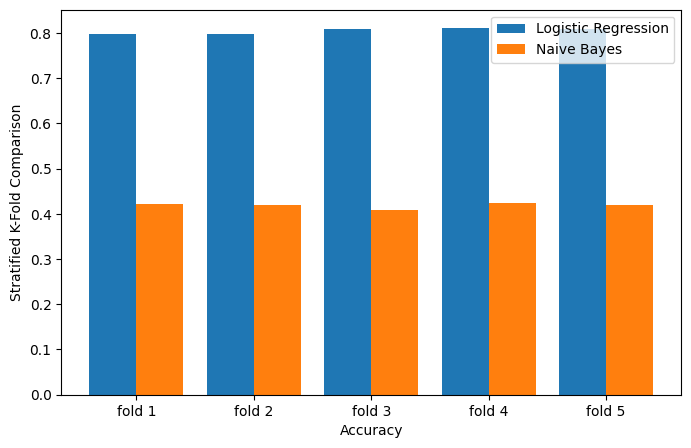

In [ ]:
# Features & Target
X_cls = X_train_cls
y_cls = y_train_cls

# Best models
log_model = LogisticRegression(C=best_C, max_iter=2000)
nb_model = gnb # best model in Naive Bayes

# divide data into 5 parts
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

log_acc = []
nb_acc = []

# Cross validation loop
# fo each time do this >> train, test and compute accuracy
for train_idx, val_idx in skf.split(X_cls,y_cls):
  X_train_fold, X_val_fold = X_cls.iloc[train_idx], X_cls.iloc[val_idx]
  y_train_fold, y_val_fold = y_cls.iloc[train_idx], y_cls.iloc[val_idx]

  # Repeat the same steps for each model (Logistic Regression & Naive Bayes)
  # Logistic regression
  log_model.fit(X_train_fold, y_train_fold)
  log_pred = log_model.predict(X_val_fold)
  log_acc.append(accuracy_score(y_val_fold,log_pred)) # collect the results (stores accuracy for each fold)

  # Naive Bayes
  nb_model.fit(X_train_fold, y_train_fold)
  nb_pred = nb_model.predict(X_val_fold)
  nb_acc.append(accuracy_score(y_val_fold,nb_pred)) # collect the results (stores accuracy for each fold)


# get results
print("___Logistic Regression___")
print("\nAccuracy per fold:", log_acc)
print("\nMean:", np.mean(log_acc))
print("\nstd:", np.std(log_acc))
print("\n___Naive Bayes___")
print("\nAccuracy per fold:", nb_acc)
print("\nMean:", np.mean(nb_acc))
print("\nstd:", np.std(nb_acc))
print("\n")
# Visualize
x=np.arange(5)
plt.figure(figsize=(8,5))
plt.bar(x-0.2, log_acc, width=0.4, label="Logistic Regression")
plt.bar(x+0.2, nb_acc, width=0.4, label="Naive Bayes")

plt.xticks(x, [f"fold {i+1}" for i in range(5)])
plt.xlabel("Accuracy")
plt.ylabel("Stratified K-Fold Comparison")
plt.legend()
plt.show()




# Task 8 : Analysis and Discussion

8.1  Model Comparison

A-

For regression tasks the best performing model overall was the Polynomial Regression  of degree 4 with Linear Regression as it achieved the highest Test R² score (0.970) indicating that it captures the non-linear relationships in the data much better than simpler models.

In comparison:

Baseline Linear Regression achieved a Test R² of 0.517 which shows only moderate performance
Ridge and Lasso improved stability through regularization but did not outperform the polynomial model in predictive power

 Therefore Polynomial Regression (degree 4) is the best regression model due to its significantly higher explanatory power and ability to model complex patterns in the dataset.

Which model performed best for classification?

For classification Logistic Regression with tuned C = 0.46 and L2 regularization performed the best overall

It achieved an accuracy of approximately 0.804
It also showed very stable results across Stratified K-Fold cross-validation with a mean accuracy of 0.805 and very low standard deviation (~0.0057) indicating strong generalization

In comparison:

Gaussian Naive Bayes achieved lower performance ~0.72 accuracy.
ComplementNB performed significantly worse ~0.51 accuracy.

 Therefore, Logistic Regression is the best classification model due to its higher accuracy and stability across folds

B-

Classification is relatively easier than regression on this dataset
This is because the classification task benefits from a clear and well-structured target definition The performance tiers (Low, Mid, High, Elite) were created using quantile-based thresholds of Overall_Rating which naturally produces well-balanced and separable classes this   result Logistic Regression achieved a stable accuracy of about 0.80 with consistent performance across folds

In contrast regression is harder because the target variable (Value Per M$) is:


Highly skewed (strong right skew ≈ 7.98)



Continuous and noisy



Influenced by more complex and non-linear relationships between features



Even the best linear model (baseline Linear Regression) achieved only a moderate R² (~0.52 on test) showing that the model struggles to capture all the variability in the target.
 Therefore:


Classification is easier due to clearer class separation and balanced data distribution


Regression is harder because the target is continuous, skewed, and more sensitive to non-linear patterns



8.2  Regularization Analysis

A-

we tested different alpha values using a log scale:

alphas = np.logspace(-3, 3, 20)

We then measured performance using Train and Test RMSE for each value.

1-Ridge Regression

ridge = Ridge(alpha=a)
ridge.fit(X_train_poly, y_train)

 we observed:

-With small alpha the model performs better (lower RMSE)

-when alpha increases performance changes slowly and stays quite stable

-Ridge reduces coefficients but does not remove features

plt.semilogx(alphas, ridge_test_rmse)

Result:

Ridge performance is stable and changes smoothly as alpha increases

2-Lasso Regression

lasso = Lasso(alpha=a, max_iter=5000)
lasso.fit(X_train_poly, y_train)

 we observed:

-With small alpha, performance is good (low RMSE)

-When alpha increases, RMSE increases more clearly than Ridge

-Lasso removes some features completely

Lasso zeroed out 7 out of 69 features

Result:

Lasso becomes more strict as alpha increases, and this can lead to underfitting when alpha is large

--Final Conclusion

Increasing alpha increases regularization strength in both models
At first it helps reduce overfitting

After a point performance gets worse:

Ridge :slow and stable change

Lasso :stronger drop because it removes features

So

Ridge is more stable with alpha changes

Lasso is more sensitive and can reduce model complexity too much


B-

Ridge usually performs better than Lasso when we have many one-hot encoded features because of how each method handles feature weights

One-hot encoding creates many highly correlated features (for example: multiple columns for Country, Team, Position)

-Ridge Regression (L2) keeps all features and only shrinks their coefficients
This means it can share importance between correlated dummy variables instead of removing them

-Lasso Regression (L1) tries to simplify the model by forcing some coefficients to become exactly zero
With many one-hot features this can be a problem because it may remove useful related features leading to loss of important information

Therefore

Ridge works better because it handles correlated one-hot features smoothly
Lasso can be too aggressive and may drop important dummy variables reducing performance